In [1]:
import HTSeq
import numpy as np

from price2.cleavage_model import CleavageEstimator
from price2.reference_annotation import ReferenceAnnotation
from price2.rgr_finder import RGRFinder

from orf_activity_estimator import ORFActivityEstimator

from matplotlib import pyplot as plt

In [2]:
gtf_file = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_real_small/homo_sapiens_chr_15.gtf'
bam_file = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_real_small/SRR10814059_15.bam'
fasta_file = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_real_small/homo_sapiens_chr_15.fasta'

In [3]:
ra = ReferenceAnnotation('/projects/viro/maidhof/price2/orf_deconvolution_development/data_real_small/homo_sapiens_chr_15.gtf')

In [4]:
ce = CleavageEstimator()
ce.collect_data(ra, HTSeq.BAM_Reader(bam_file))
ce.correct_table()

In [5]:
cm = ce.run()


In [6]:
genome = dict((s.name, s) for s in HTSeq.FastaReader(fasta_file))
rgr_finder = RGRFinder(ra.transcripts, genome)

In [7]:
oae = ORFActivityEstimator(
    cm,
    ra,
    rgr_finder,
    bam_file,
)

In [8]:
oae.fill_groups()

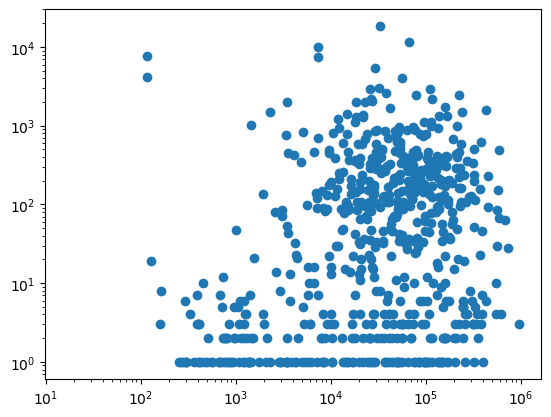

In [9]:
plt.scatter([len(locus) for locus in oae.loci_set], [locus.read_count for locus in oae.loci_set])
plt.xscale('log')
plt.yscale('log')

In [10]:
from tqdm.contrib.concurrent import process_map
from multiprocessing import Pool

def helper(locus):
    locus.run_orf_deconvolution(1000, .005, cm)

with Pool(50) as p:
    process_map(helper, oae.loci_set, max_workers=50)


/home/maidhof/mambaforge/envs/general/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_1403904/4160667747.py:8: TqdmWarning: Iterable length 1583 > 1000 but `chunksize` is not set. This may seriously degrade multiprocess performance. Set `chunksize=1` or more.
  process_map(helper, oae.loci_set, max_workers=50)
  0%|          | 0/1583 [00:00<?, ?it/s]/projects/viro/maidhof/price2/orf_deconvolution_development/orf_activity_estimator.py:79: RuntimeWarning: invalid value encountered in scalar divide
  p = {region: likelihoods[region]/likelihood_sum for region in likelihoods}
/projects/viro/maidhof/price2/orf_deconvolution_development/orf_activity_estimator.py:79: RuntimeWarning: invalid value encountered in scalar divide
  p = {region: likelihoods[region]/likelihood_sum for region in likeliho

In [13]:
loc = list(oae.loci_set)[0]

In [27]:
read_counts = np.array([loc.read_count for loc in oae.loci_set])
(read_counts<50).sum()

1276

In [12]:
len(loc.regions)
#for loc in oae.loci_set:
#    print(len(loc.regions))
bla = np.array([len(loc) for loc in oae.loci_set])
bla.sort()
bla


array([    17,     17,     19, ..., 686432, 741036, 949080])